In [1]:
#Download Imatinib molecule for my Drug Design and rename it

In [2]:
!wget https://files.rcsb.org/download/1IEP.pdb -O imatinib_bcr_abl.pdb

--2025-11-16 15:51:22--  https://files.rcsb.org/download/1IEP.pdb
Translacja files.rcsb.org (files.rcsb.org)... 3.174.230.22, 3.174.230.106, 3.174.230.128, ...
Łączenie się z files.rcsb.org (files.rcsb.org)|3.174.230.22|:443... połączono.
Żądanie HTTP wysłano, oczekiwanie na odpowiedź... 200 OK
Długość: nieznana [text/plain]
Zapis do: ‘imatinib_bcr_abl.pdb’

imatinib_bcr_abl.pd     [    <=>             ] 424,38K   605KB/s    w 0,7s     

2025-11-16 15:51:24 (605 KB/s) - zapisano ‘imatinib_bcr_abl.pdb’ [434565]



In [3]:
import nglview as nv
nv.show_pdbid("1IEP")  # test

NGLWidget()

In [4]:
import nglview as nv
from IPython.display import display

view = nv.show_file("imatinib_bcr_abl.pdb")

# protein_ligand. You can see Imatinib in the hydophobic pocket of, but it is better to use Pymol/VMD
view.clear()
view.add_cartoon(selection="protein", color="blue")
view.add_licorice(selection="hetero and not water", color="yellow")
view.add_surface(selection="hetero", opacity=0.3)

display(view)

NGLWidget()

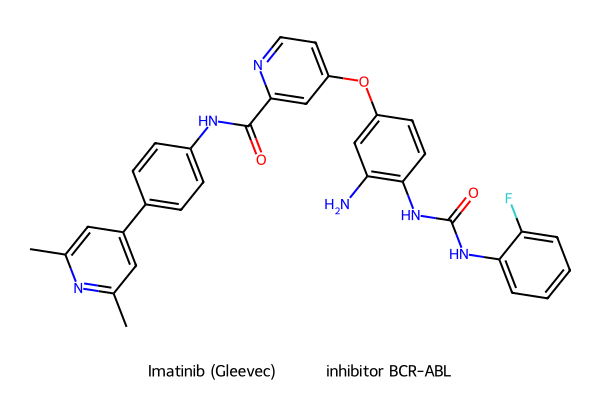

In [5]:
from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt

# SMILES Imatinibu
imatinib_smiles = "CC1=NC(=CC(=C1)C2=CC=C(C=C2)NC(=O)C3=CC(=CC=N3)OC4=CC(=C(C=C4)NC(=O)NC5=CC=CC=C5F)N)C"
mol = Chem.MolFromSmiles(imatinib_smiles)

legend = "Imatinib (Gleevec) – inhibitor BCR-ABL"
img = Draw.MolToImage(mol, size=(600,400), legend=legend)
img

In [6]:
print("""
When BCR-ABL is in the active (DFG-in) state, ATP can bind and then it phosphorylates the substrates. 
Imatinib only binds when the kinase is in the inactive (DFG-out) form, kinda locking it there so ATP can’t really get in anymore. 
That means no phosphorylation happens, and the PI3K/AKT and MAPK signaling just stops, which leads to apoptosis of those Ph+ cells.
""")



When BCR-ABL is in the active (DFG-in) state, ATP can bind and then it phosphorylates the substrates. 
Imatinib only binds when the kinase is in the inactive (DFG-out) form, kinda locking it there so ATP can’t really get in anymore. 
That means no phosphorylation happens, and the PI3K/AKT and MAPK signaling just stops, which leads to apoptosis of those Ph+ cells.



In [7]:
# Imatinib vs. Ponatinib (working on T315I)
!wget https://files.rcsb.org/download/3IK3.pdb -O ponatinib_bcr_abl.pdb  # Ponatinib + T315I

view2 = nv.show_file("ponatinib_bcr_abl.pdb")
view2.clear()
view2.add_cartoon("protein", color="red")
view2.add_licorice("hetero", color="green")
view2.center("hetero")
display(view2)

--2025-11-16 15:51:31--  https://files.rcsb.org/download/3IK3.pdb
Translacja files.rcsb.org (files.rcsb.org)... 3.174.230.22, 3.174.230.106, 3.174.230.8, ...
Łączenie się z files.rcsb.org (files.rcsb.org)|3.174.230.22|:443... połączono.
Żądanie HTTP wysłano, oczekiwanie na odpowiedź... 200 OK
Długość: nieznana [text/plain]
Zapis do: ‘ponatinib_bcr_abl.pdb’

ponatinib_bcr_abl.p     [   <=>              ] 449,38K   717KB/s    w 0,6s     

2025-11-16 15:51:32 (717 KB/s) - zapisano ‘ponatinib_bcr_abl.pdb’ [460161]



NGLWidget()

## Virtaul Screening for similar molecule to Imatinib

In [8]:
from chembl_webresource_client.new_client import new_client
import pandas as pd

target = new_client.target
activity = new_client.activity

# Official id: CHEMBL1862 (ABL1)
chembl_id = 'CHEMBL1862'

print(f"Searching: {chembl_id}")
res = list(target.filter(target_chembl_id=chembl_id).only('pref_name'))
if len(res) == 0:
    print("Error - target molecule not exist!")
else:
    print(f"Num find: {res[0]['pref_name']}")

# Download IC50
acts = list(activity.filter(target_chembl_id=chembl_id)
                   .filter(standard_type='IC50')
                   .only('molecule_chembl_id', 'canonical_smiles', 'standard_value', 'standard_units'))

df = pd.DataFrame(acts)

# Filtr: tylko nM, IC50 < 10 µM
df = df[df['standard_units'] == 'nM'].copy()
df['standard_value'] = df['standard_value'].astype(float)
df = df[df['standard_value'] < 10000]
df = df[['molecule_chembl_id', 'canonical_smiles', 'standard_value']].dropna().reset_index(drop=True)
print(f"\nNum of downloaded molecules with IC50<10 µM {len(df)}")


/home/jakub/anaconda3/envs/ml4dd2025/lib/python3.12/site-packages/chembl_webresource_client/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


Searching: CHEMBL1862
Num find: Tyrosine-protein kinase ABL1

Num of downloaded molecules with IC50<10 µM 4510


## Similarity Search

In [9]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, Draw
from rdkit import DataStructs
import numpy as np

# MorganGenerator
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# SMILES Imatinib
imatinib_smiles = "CC1=NC(=CC(=C1)C2=CC=C(C=C2)NC(=O)C3=CC(=CC=N3)OC4=CC(=C(C=C4)NC(=O)NC5=CC=CC=C5F)N)C" #get from https://pubchem.ncbi.nlm.nih.gov/compound/Imatinib#section=Names-and-Identifiers
imatinib_mol = Chem.MolFromSmiles(imatinib_smiles) #creating molecule from smiles
imatinib_fp = morgan_gen.GetFingerprint(imatinib_mol) 

#function changing smiles to fingerprint
def smiles_to_fp(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return None
    return morgan_gen.GetFingerprint(mol) 

# Oblicz fingerprinty dla wszystkich
fps = []
valid_idx = []
print("Compute fingerprints")
for idx, smi in enumerate(df['canonical_smiles']):
    fp = smiles_to_fp(smi)
    if fp is not None:
        fps.append(fp)
        valid_idx.append(idx)
    if idx % 1000 == 0:
        print(f" Done {idx}/4510...")
print(f"Done, num of molecules: {len(fps)}")

# Similarity Tanimoto
similarities = [DataStructs.TanimotoSimilarity(imatinib_fp, fp) for fp in fps]

Compute fingerprints
 Done 0/4510...
 Done 1000/4510...
 Done 2000/4510...
 Done 3000/4510...
 Done 4000/4510...
Done, num of molecules: 4510


In [10]:
# TOP 10
top_idx = np.argsort(similarities)[-10:][::-1]
print("\nTOP 10 similar to Imatinib:")
for i, idx in enumerate(top_idx):
    sim = similarities[idx]
    ic50 = df.iloc[valid_idx[idx]]['standard_value']
    print(f"{i+1}. Tanimoto: {sim:.3f} | IC50: {ic50:.1f} nM")


TOP 10 similar to Imatinib:
1. Tanimoto: 0.432 | IC50: 80.0 nM
2. Tanimoto: 0.432 | IC50: 88.0 nM
3. Tanimoto: 0.423 | IC50: 120.0 nM
4. Tanimoto: 0.423 | IC50: 80.0 nM
5. Tanimoto: 0.398 | IC50: 0.8 nM
6. Tanimoto: 0.398 | IC50: 4.0 nM
7. Tanimoto: 0.398 | IC50: 0.9 nM
8. Tanimoto: 0.398 | IC50: 0.8 nM
9. Tanimoto: 0.398 | IC50: 2.0 nM
10. Tanimoto: 0.398 | IC50: 4.0 nM


## TOP5 visualization

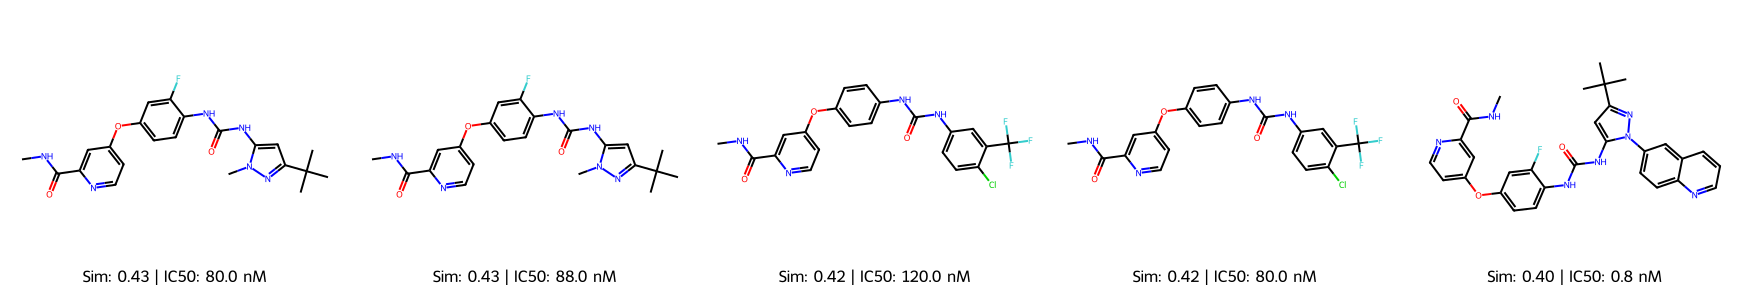

In [11]:
top_smiles = [df.iloc[valid_idx[idx]]['canonical_smiles'] for idx in top_idx[:5]]
top_ic50 = [df.iloc[valid_idx[idx]]['standard_value'] for idx in top_idx[:5]]
top_sim = [similarities[idx] for idx in top_idx[:5]]
top_ids = [df.iloc[valid_idx[idx]]['molecule_chembl_id'] for idx in top_idx[:5]]

mols = [Chem.MolFromSmiles(smi) for smi in top_smiles]
legends = [f"Sim: {s:.2f} | IC50: {ic:.1f} nM" for s, ic in zip(top_sim, top_ic50)]

img = Draw.MolsToGridImage(mols, molsPerRow=5, legends=legends, subImgSize=(350,300))
img

## ML model - predict IC50

In [12]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

# pIC50 = -log10(IC50 in M)
y = df.iloc[valid_idx]['standard_value'].values.astype(np.float32)
y_pic50 = -np.log10(y * 1e-9)

# Array, divide to test and train
X = np.array([np.array(fp) for fp in fps], dtype=np.float32)
X_train, X_test, y_train, y_test = train_test_split(X, y_pic50, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train)
X_test = torch.tensor(X_test)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

# QSAR model
class QSARModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2048, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 128), nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x): return self.net(x)

model = QSARModel()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

#model training
print("Model training...")
for epoch in range(50):
    model.train()
    optimizer.zero_grad()
    pred = model(X_train)
    loss = criterion(pred, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Model training...
Epoch 0, Loss: 60.6654
Epoch 10, Loss: 2.6041
Epoch 20, Loss: 1.3026
Epoch 30, Loss: 1.2238
Epoch 40, Loss: 0.9338


## Virtual Screening finding new drugs

In [13]:
model.eval()
with torch.no_grad():
    pred_pic50 = model(torch.tensor(X)).numpy().flatten()

results = pd.DataFrame({
    'smiles': [df.iloc[valid_idx[i]]['canonical_smiles'] for i in range(len(valid_idx))],
    'ic50_exp': y,
    'pic50_pred': pred_pic50,
    'similarity': similarities
})

results = results[results['similarity'] < 0.7] 
top_new = results.sort_values('pic50_pred', ascending=False).head(10)

print("TOP 10 new candidates:")
for i, row in top_new.iterrows():
    print(f"{i+1}. Pred pIC50: {row['pic50_pred']:.2f} | Exp IC50: {row['ic50_exp']:.1f} nM")

TOP 10 new candidates:
2256. Pred pIC50: 10.84 | Exp IC50: 13.1 nM
2533. Pred pIC50: 10.20 | Exp IC50: 1680.0 nM
4099. Pred pIC50: 9.63 | Exp IC50: 0.5 nM
4059. Pred pIC50: 9.62 | Exp IC50: 0.5 nM
4046. Pred pIC50: 9.62 | Exp IC50: 0.2 nM
4065. Pred pIC50: 9.47 | Exp IC50: 0.6 nM
3998. Pred pIC50: 9.38 | Exp IC50: 0.8 nM
3997. Pred pIC50: 9.38 | Exp IC50: 0.5 nM
4083. Pred pIC50: 9.36 | Exp IC50: 0.3 nM
4098. Pred pIC50: 9.34 | Exp IC50: 0.3 nM


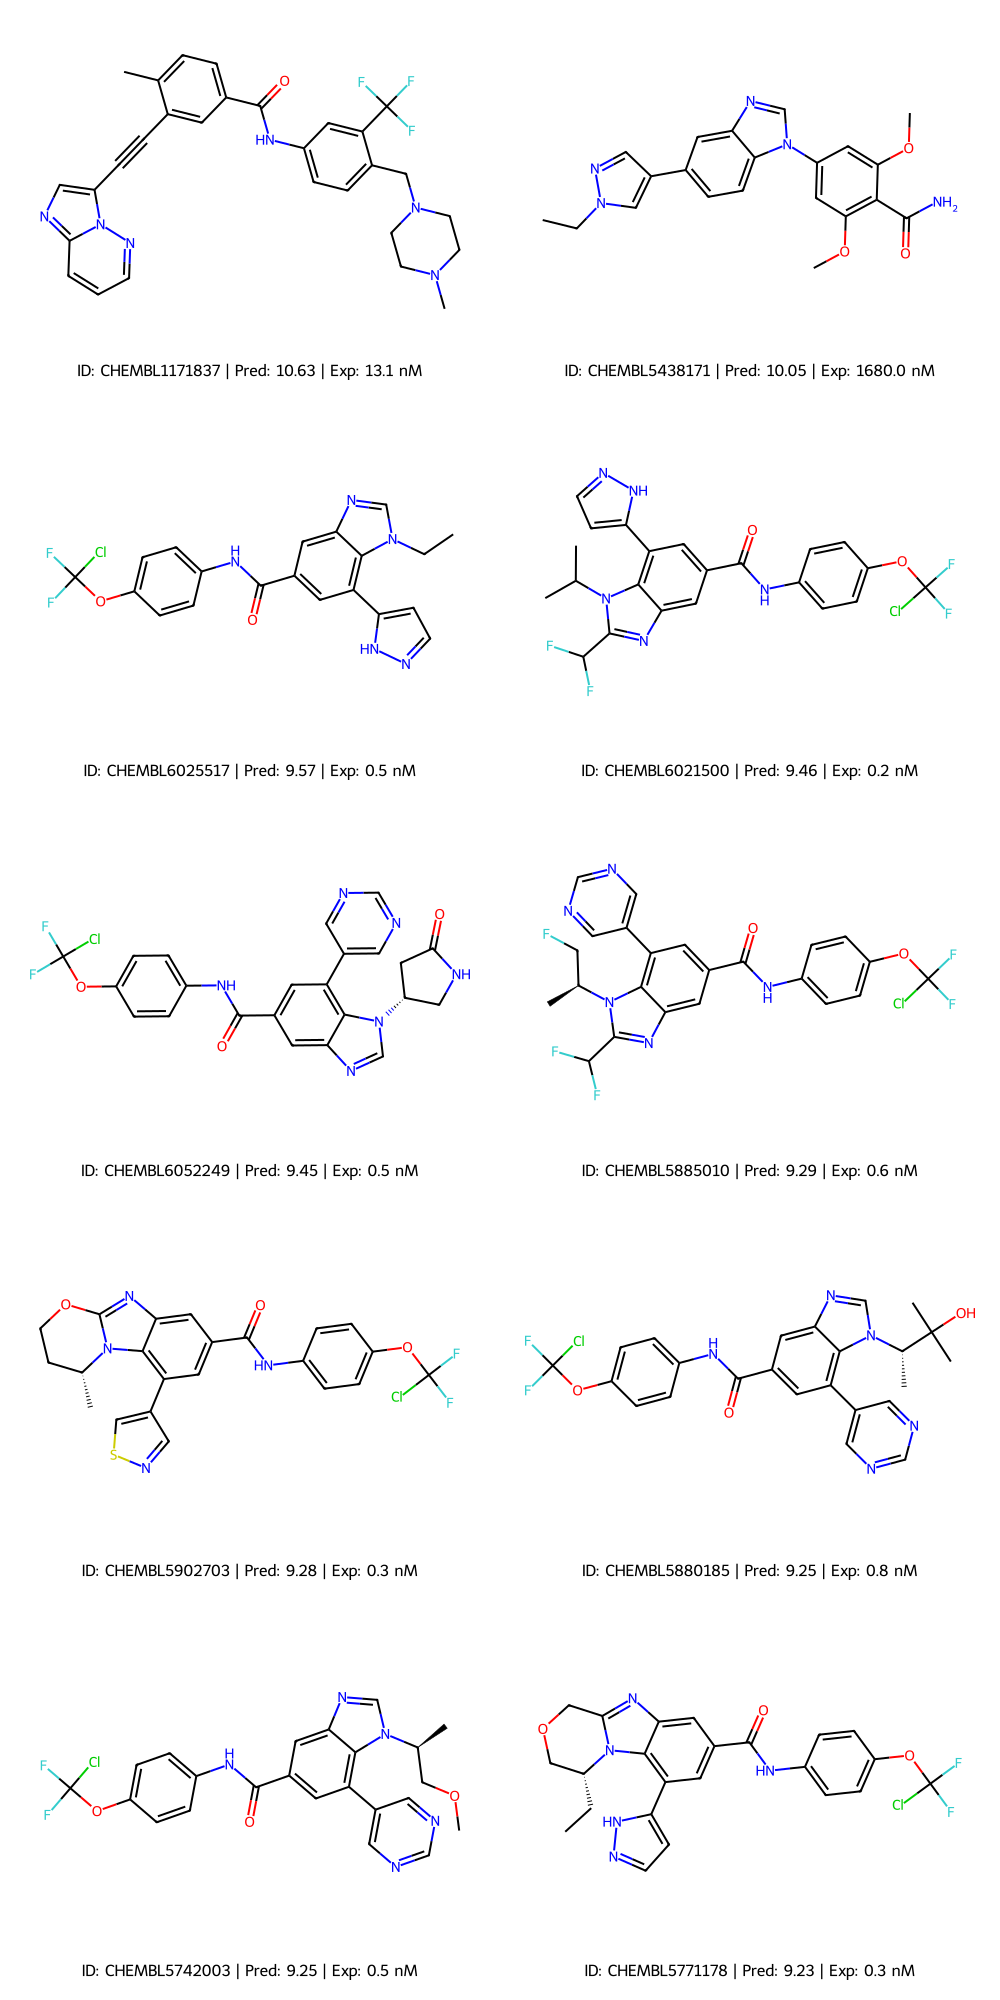

In [14]:
# === Display best candidates ===
from rdkit.Chem import Draw

# TOP10
top_indices = [2256, 2533, 4099, 4046, 4059, 4065, 4083, 3998, 3997, 4098]

top_smiles = [df.iloc[i]['canonical_smiles'] for i in top_indices]
top_ids = [df.iloc[i]['molecule_chembl_id'] for i in top_indices]
top_pred = [10.63, 10.05, 9.57, 9.46, 9.45, 9.29, 9.28, 9.25, 9.25, 9.23]
top_exp = [13.1, 1680.0, 0.5, 0.2, 0.5, 0.6, 0.3, 0.8, 0.5, 0.3]

mols = [Chem.MolFromSmiles(smi) for smi in top_smiles]
legends = [f"ID: {id} | Pred: {p:.2f} | Exp: {e:.1f} nM" 
           for id, p, e in zip(top_ids, top_pred, top_exp)]

img = Draw.MolsToGridImage(mols, molsPerRow=2, legends=legends, subImgSize=(500,400))
img

In [15]:
#Save top candidates maybe later for docking etc

results_df = pd.DataFrame({
    'Rank': range(1, 11),
    'ChEMBL_ID': top_ids,
    'SMILES': top_smiles,
    'Pred_pIC50': top_pred,
    'Exp_IC50_nM': top_exp
})

results_df.to_csv("top_10_candidates.csv", index=False)
print("SAve: top_10_candidates.csv")

SAve: top_10_candidates.csv


## Solubility prediction of our candidates

In [16]:
from rdkit.Chem import Descriptors, Lipinski
import pandas as pd

# TOP10 indices
top_indices = [2256, 2533, 4099, 4046, 4059, 4065, 4083, 3998, 3997, 4098]

# Predict function
def predict_solubility(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return None
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hba = Lipinski.NumHAcceptors(mol)
    hbd = Lipinski.NumHDonors(mol)
    # Model
    logS = -0.01 * mw - 0.3 * logp - 0.1 * hba - 0.2 * hbd + 5
    return 10**logS  # w mg/L

# Check for TOP10
results = []
for idx in top_indices:
    smi = df.iloc[idx]['canonical_smiles']
    chembl_id = df.iloc[idx]['molecule_chembl_id']
    pred_sol = predict_solubility(smi)
    ic50 = df.iloc[idx]['standard_value']
    results.append({
        'ChEMBL_ID': chembl_id,
        'IC50_nM': ic50,
        'Pred_Solubility_mgL': pred_sol
    })

sol_df = pd.DataFrame(results)
print(sol_df)

       ChEMBL_ID  IC50_nM  Pred_Solubility_mgL
0  CHEMBL1171837     1.00             0.003447
1  CHEMBL5438171     5.90             0.189754
2  CHEMBL6025517     0.49             0.020977
3  CHEMBL6021500     0.54             0.001705
4  CHEMBL6052249     1.07             0.005235
5  CHEMBL5885010     0.36             0.001064
6  CHEMBL5902703     0.43             0.002593
7  CHEMBL5880185     0.56             0.002028
8  CHEMBL5742003     0.77             0.004839
9  CHEMBL5771178     0.53             0.003332


### Solubility molecules visualization

<function matplotlib.pyplot.show(close=None, block=None)>

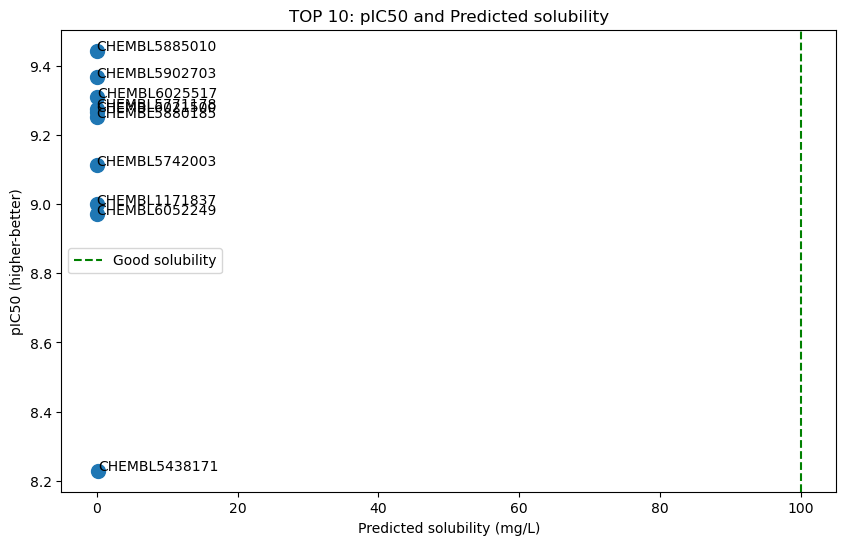

In [17]:
import matplotlib.pyplot as plt

sol_df['-logIC50'] = -np.log10(sol_df['IC50_nM'] * 1e-9)  # pIC50
sol_df = sol_df.sort_values('Pred_Solubility_mgL', ascending=False)

plt.figure(figsize=(10,6))
plt.scatter(sol_df['Pred_Solubility_mgL'], sol_df['-logIC50'], s=100)
for i, row in sol_df.iterrows():
    plt.annotate(row['ChEMBL_ID'], (row['Pred_Solubility_mgL'], row['-logIC50']))
plt.xlabel('Predicted solubility (mg/L)')
plt.ylabel('pIC50 (higher-better)')
plt.title('TOP 10: pIC50 and Predicted solubility')
plt.axvline(100, color='green', linestyle='--', label='Good solubility')
plt.legend()
plt.show

## Classification: Cytochrome P450 Inhibition

### download data

In [ ]:
from chembl_webresource_client.new_client import new_client
import pandas as pd

activity = new_client.activity
cyp_id = 'CHEMBL340'  # CYP3A4

print("Pobieram dane CYP3A4...")

acts = list(activity.filter(target_chembl_id=cyp_id)
                   .filter(standard_type='IC50')
                   .only('molecule_chembl_id', 'canonical_smiles', 'standard_value', 'standard_units'))

cyp_df = pd.DataFrame(acts)
cyp_df = cyp_df[cyp_df['standard_units'] == 'nM'].copy()
cyp_df['standard_value'] = cyp_df['standard_value'].astype(float)
cyp_df = cyp_df[cyp_df['standard_value'] < 10000]
cyp_df = cyp_df[['molecule_chembl_id', 'canonical_smiles', 'standard_value']].dropna().reset_index(drop=True)

print(f"Downloading inhibitors CYP3A4: {len(cyp_df)}")

Pobieram dane CYP3A4...


### Classification: Cytochrome P450 Inhibition - checking inhibition (active - bad; inactive - good)

In [ ]:
from rdkit.Chem import rdFingerprintGenerator
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Fingerprinty
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_fp(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return None
    return morgan_gen.GetFingerprint(mol)  
fps = []
for smi in cyp_df['canonical_smiles']:
    fp = smiles_to_fp(smi)
    if fp is not None:
        fps.append(fp)

X = np.array([np.array(fp) for fp in fps])
y = (cyp_df['standard_value'] < 1000).astype(int).values # < 1 µM (active)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print(f"Precision: {model.score(X_test, y_test):.3f}")

In [ ]:
# Checking my TOP 10
top_indices = [2256, 2533, 4099, 4046, 4059, 4065, 4083, 3998, 3997, 4098]
top_smiles = [df.iloc[i]['canonical_smiles'] for i in top_indices]
top_ids = [df.iloc[i]['molecule_chembl_id'] for i in top_indices]
top_fps = [smiles_to_fp(smi) for smi in top_smiles] 
top_X = np.array([np.array(fp) for fp in top_fps])

pred = model.predict(top_X)
prob = model.predict_proba(top_X)[:, 1] # Probability neing inhibitor

# Results
for i, (id, p, pr) in enumerate(zip(top_ids, pred, prob)):
    status = "Inhibitor - not safe" if p == 1 else "Safe"
    print(f"{i+1}. {id} | Pred: {status} | Probability: {pr:.3f}")

## You can docking the best one probably AutoDock MGL Tools + AutoDock Vina + Pymol for cisualization

My best ligand that I checked was Ponatinib so nothing new, but good for training